In [2]:
#Проверка дял трёхтельного угла (Угла Лапласа)
import sys
from pathlib import Path
PROJECT_ROOT = Path().absolute().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from src.time_series import load_multi_csv, load_angles
from src.sliding_window import sliding_windows_multiplet
from src.inference import load_model, predict_multiplet, predict_classes_from_proba
from src.visual import plot_raw_multiplet, plot_multiplet_predictions, plot_angles
from src.criteria import process_multiplet

2026-05-05 01:48:24.269275: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [11]:
data_path=str(PROJECT_ROOT)+'/time_series/TOI-1136_arg_p_max_history_threebody_2_2_planets_1_2_3.npz'
data = load_angles(data_path, ['Phi'], time_column='time_years',angle_unit='deg',convert_to_xy=True)

In [12]:
data #TOI1136 b-c-d| p=2; q=2; p+q= 4 PHI=p*lambda_b-(p+q)*lambda_c+q*lambda_d

{'angles_deg': [array([ -551.1832 , -1239.0297 , -1242.4026 , ...,   230.37723,
          -523.75824,   204.89299], shape=(400000,), dtype=float32)],
 'angle_names': ['Phi'],
 'angles_xy': [array([[-0.98101205,  0.19394684],
         [-0.9337657 , -0.35788482],
         [-0.95320415, -0.3023273 ],
         ...,
         [-0.63773024, -0.7702598 ],
         [-0.96009016, -0.2796908 ],
         [-0.90709555, -0.42092475]], shape=(400000, 2), dtype=float32)],
 'time_years': array([0.0000000e+00, 2.5002053e+00, 5.0001917e+00, ..., 9.9999250e+05,
        9.9999500e+05, 9.9999750e+05], shape=(400000,), dtype=float32)}

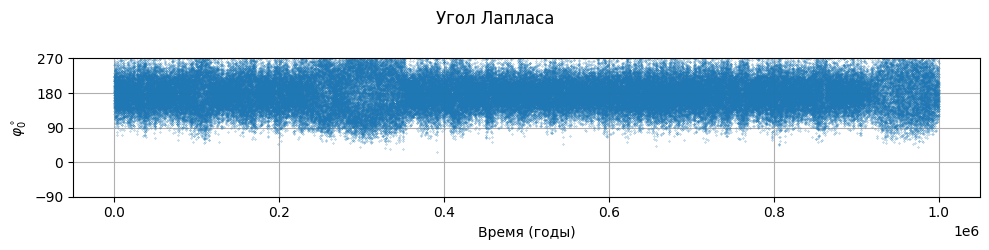

In [10]:
plot_angles(data['time_years'], data['angles_deg'], title='Угол Лапласа')

In [13]:
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.
)

In [15]:
# windows

In [16]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')

W0000 00:00:1777928168.200708  247174 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [17]:
probs = predict_multiplet(windows['angle_windows'], model)

2026-05-05 01:56:18.513489: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-05-05 01:56:18.547164: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-05-05 01:56:18.644369: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-05-05 01:56:18.686345: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-05-05 01:56:18.765397: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.


In [18]:
classes = [predict_classes_from_proba(p) for p in probs]

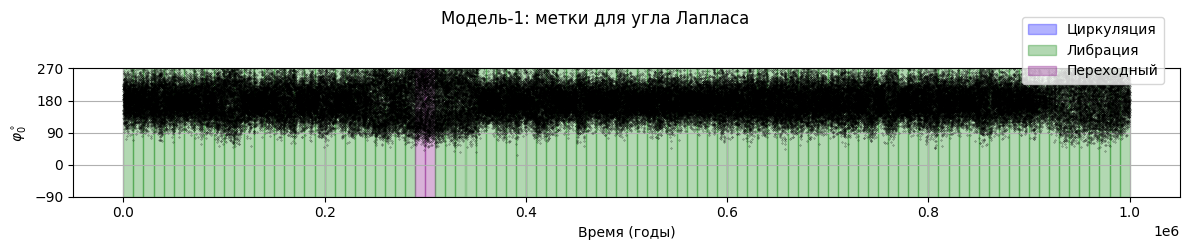

In [19]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Модель-1: метки для угла Лапласа',
    # save_path='/content/drive/MyDrive/Diplom_data/resonance_sorter/notebook/predict_TOI1136_model1.png'

)

In [20]:
#Переход как два центра либрации